# Banking Dataset Enterprise Category Normalization

## Objective

This notebook standardizes overlapping banking categories into:

```text
5 Enterprise-Level Categories
```

The goal is to:
- reduce semantic overlap
- improve ML model accuracy
- improve semantic retrieval
- improve RAG quality
- improve chatbot consistency

---

# Why This Is Needed?

The original dataset contains overlapping categories such as:

- accounts
- cards
- digital banking
- security
- customer service
- investments
- general finance

These overlaps:
- confuse ML models
- reduce intent accuracy
- create semantic ambiguity

---

# Enterprise Solution

Instead of:
```text
LLM call for every row
```

We use:
```text
Enterprise Taxonomy Mapping
```

This is:
- faster
- scalable
- deterministic
- enterprise-grade

---

# Final Standard Categories

| Standard Category | Covers |
|---|---|
| Accounts & Cards | accounts, cards, deposits |
| Digital Payments & Transfers | UPI, IMPS, transfers |
| Loans & Investments | loans, EMI, stocks |
| Security & Customer Support | fraud, KYC, complaints |
| Insurance & Financial Services | insurance, forex, govt schemes |

---

# Final Output

```text
banking_llm_classified.csv
```

### Import Libraries

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Environment Variables
import os

# Progress Bar
from tqdm import tqdm

# dotenv
from dotenv import load_dotenv

# Groq LLM
from langchain_groq import ChatGroq

# Warnings
import warnings
warnings.filterwarnings("ignore")

### Load Environment Variables

In [3]:
load_dotenv()

GROQ_API_KEY = os.getenv("GROQ_API_KEY")

print("Environment Variables Loaded Successfully")

Environment Variables Loaded Successfully


### Load Dataset

In [4]:
df = pd.read_csv("../data/processed_data/01_banking_cleaned.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


### Display Dataset Information

In [5]:
print("Dataset Shape:", df.shape)
df.sample(5)

Dataset Shape: (2332, 6)


,Category,Question,Answer,question_length,answer_length,clean_question
2125,Financial Markets,What is commodity trading?,Commodity trading involves buying and selling ...,26,153,commodity trading
1599,Loans & Interest,What is a Kisan Credit Card?,Kisan Credit Card is a scheme giving farmers e...,28,157,kisan credit card
1171,loans,Will we get tax benefit on the interest paid o...,"Yes, every Credila borrower or co-borrower (an...",62,115,tax benefit interest pay education loan
294,cards,"Except for digital media consumption, what is ...",M&N bank Times Points Debit Card gives custom...,86,246,digital medium consumption medium earn time point
1015,investments,When will the Bank lock money in my Account fo...,The Bank will need the money in your account a...,61,463,bank lock money account asba payment


### Dataset Overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2332 entries, 0 to 2331
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Category         2332 non-null   object
 1   Question         2332 non-null   object
 2   Answer           2332 non-null   object
 3   question_length  2332 non-null   int64 
 4   answer_length    2332 non-null   int64 
 5   clean_question   2331 non-null   object
dtypes: int64(2), object(4)
memory usage: 109.4+ KB


### Check Missing Values

In [7]:
df.isnull().sum()

Category           0
Question           0
Answer             0
question_length    0
answer_length      0
clean_question     1
dtype: int64

In [8]:
df[df.isnull().any(axis=1)]

,Category,Question,Answer,question_length,answer_length,clean_question
1823,General Finance,What is a will?,A will is a legal document stating how you wan...,15,149,NaN


In [9]:
df.dropna(inplace=True)

### Analyze Existing Categories

In [12]:
df["Category"].nunique()

17

In [13]:
unique_categories = df["Category"].unique()
unique_categories

array(['accounts', 'cards', 'fundstransfer', 'insurance', 'investments',
       'loans', 'security', 'Basic Accounts', 'Digital Banking',
       'Loans & Interest', 'Operations & Security', 'General Finance',
       'Customer Service', 'Insurance & Govt Schemes',
       'International Banking', 'Financial Markets',
       'Banking Terminology'], dtype=object)

### Category Distribution

In [ ]:
category_counts = df["Category"].value_counts()

category_counts

Category
insurance                   382
cards                       310
accounts                    235
loans                       208
investments                 137
Basic Accounts              121
Digital Banking             116
Loans & Interest            110
Operations & Security       108
General Finance             105
Customer Service             91
Financial Markets            88
Insurance & Govt Schemes     86
Banking Terminology          86
International Banking        77
security                     57
fundstransfer                14
Name: count, dtype: int64

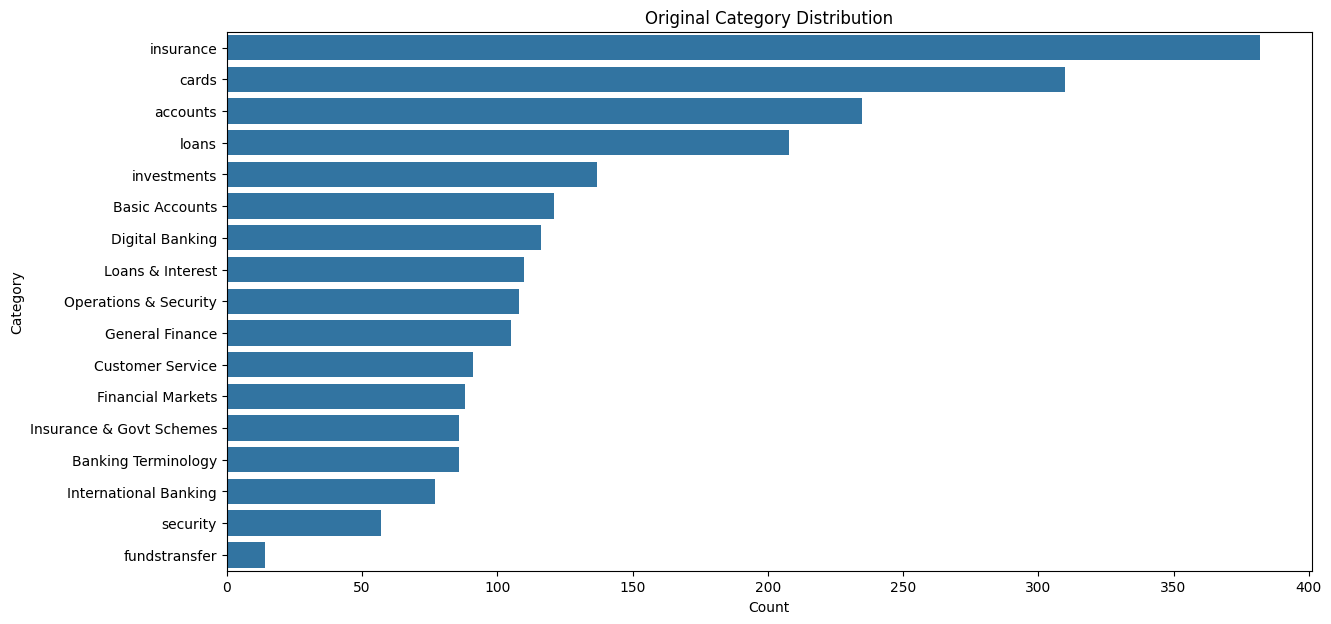

In [ ]:
plt.figure(figsize=(14, 7))

sns.countplot(y=df["Category"], order=df["Category"].value_counts().index)

plt.title("Original Category Distribution")
plt.xlabel("Count")
plt.ylabel("Category")

plt.show()

# Why Category Normalization?

The dataset currently contains:
- overlapping categories
- semantically similar labels
- inconsistent taxonomy

Examples:
- accounts
- Basic Accounts

or:
- cards
- Customer Service

These overlaps reduce:
- ML accuracy
- retrieval quality
- chatbot consistency

---

# Enterprise Solution

Use LLM semantic understanding to:
- automatically normalize labels
- create standard enterprise categories
- handle future unseen labels

# Enterprise Standard Categories

The system will reduce all categories into:

| Standard Category | Description |
|---|---|
| Accounts & Cards | Accounts, debit cards, credit cards, deposits |
| Digital Payments & Transfers | UPI, IMPS, RTGS, transfers, digital banking |
| Loans & Investments | Loans, EMI, mutual funds, stocks |
| Security & Customer Support | Fraud, KYC, complaints, customer support |
| Insurance & Financial Services | Insurance, forex, govt schemes, finance |

---

# Goal

Reduce ambiguity while preserving semantic meaning.

### Create Standard Category

In [24]:
category_mapping = {

    # Retail Banking
    "accounts": "Retail Banking",
    "Basic Accounts": "Retail Banking",

    # Cards & Payments
    "cards": "Cards & Payments",
    "fundstransfer": "Cards & Payments",

    # Loans
    "loans": "Loans",
    "Loans & Interest": "Loans",

    # Investments & Insurance
    "investments": "Investments & Insurance",
    "insurance": "Investments & Insurance",
    "Insurance & Govt Schemes": "Investments & Insurance",
    "Financial Markets": "Investments & Insurance",

    # Digital & Security
    "security": "Digital & Security",
    "Digital Banking": "Digital & Security",
    "Operations & Security": "Digital & Security",

    # Customer Support & General Banking
    "Customer Service": "Customer Support",
    "General Finance": "Customer Support",
    "International Banking": "Customer Support",
    "Banking Terminology": "Customer Support"
}

#### Apply Category Mapping

In [ ]:
df["standard_category"] = df["Category"].map(category_mapping)

print("Enterprise Category Mapping Applied Successfully")

Enterprise Category Mapping Applied Successfully


In [ ]:
df[["Category", "standard_category"]].sample(5)

,Category,standard_category
405,cards,Cards & Payments
519,cards,Cards & Payments
1389,Basic Accounts,Retail Banking
1833,General Finance,Customer Support
1770,General Finance,Customer Support


#### Check Missing Standard Categories

In [ ]:
df["standard_category"].isnull().sum()

0

### Load Groq LLM

In [ ]:
llm = ChatGroq(groq_api_key=GROQ_API_KEY, model_name="llama-3.3-70b-versatile", temperature=0)

print("Groq LLM Loaded Successfully")

Groq LLM Loaded Successfully


### Create Prompt

In [31]:
classification_prompt = """

You are a banking operations expert.

Classify the given banking category into ONLY ONE of the following departments:

1. Retail Banking
2. Cards & Payments
3. Loans
4. Investments & Insurance
5. Digital & Security
6. Customer Support
7. Other

Department Definitions:

- Retail Banking:
  Savings accounts, current accounts, account opening, account maintenance, basic banking services.

- Cards & Payments:
  Debit cards, credit cards, ATM cards, UPI, NEFT, RTGS, IMPS, fund transfers, payment issues.

- Loans:
  Personal loans, home loans, education loans, loan applications, loan repayment, interest rates.

- Investments & Insurance:
  Mutual funds, fixed deposits, bonds, insurance products, government schemes, financial markets.

- Digital & Security:
  Internet banking, mobile banking, login issues, passwords, OTP, fraud prevention, cybersecurity.

- Customer Support:
  General banking queries, customer service requests, banking terminology, international banking, miscellaneous support.

- Other:
  Use ONLY when the category cannot be confidently mapped to any of the above departments.

Rules:
- Return ONLY the department name.
- No explanation.
- No reasoning.
- No additional text.
- Output must exactly match one of the department names listed above.
- If the category is ambiguous, unknown, new, or does not clearly belong to any department, return "Other".

Category:
{category}

"""

### LLM Classification Function

In [ ]:
def classify_unknown_category(category):
    prompt = classification_prompt.format(category=category)
    response = llm.invoke(prompt)

    return response.content.strip()

### Detect Unknown Categories

In [ ]:
unknown_categories = [
    category
    for category in unique_categories
    if category not in category_mapping
]

print(f"Unknown Categories: {unknown_categories}")

Unknown Categories:
[]


#### Handle Unknown Categories

In [ ]:
for category in unknown_categories:
    predicted_category = classify_unknown_category(category)
    category_mapping[category] = predicted_category

print("Unknown Categories Processed Successfully")

Unknown Categories Processed Successfully


In [ ]:
category_mapping

{'accounts': 'Retail Banking',
 'Basic Accounts': 'Retail Banking',
 'cards': 'Cards & Payments',
 'fundstransfer': 'Cards & Payments',
 'loans': 'Loans',
 'Loans & Interest': 'Loans',
 'investments': 'Investments & Insurance',
 'insurance': 'Investments & Insurance',
 'Insurance & Govt Schemes': 'Investments & Insurance',
 'Financial Markets': 'Investments & Insurance',
 'security': 'Digital & Security',
 'Digital Banking': 'Digital & Security',
 'Operations & Security': 'Digital & Security',
 'Customer Service': 'Customer Support',
 'General Finance': 'Customer Support',
 'International Banking': 'Customer Support',
 'Banking Terminology': 'Customer Support'}

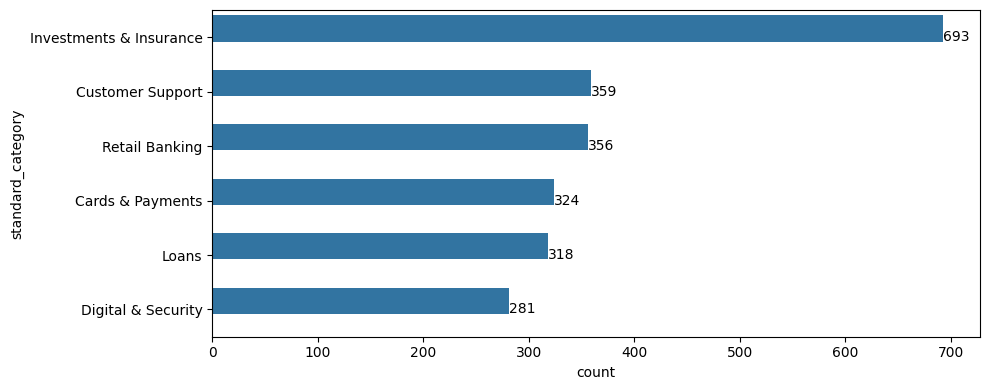

In [ ]:
plt.figure(figsize=(10, 4))

ax = sns.countplot(y=df["standard_category"], order=df["standard_category"].value_counts().index)

# Make bars thinner
for container in ax.containers:
    ax.bar_label(container)

for patch in ax.patches:
    current_height = patch.get_height()
    patch.set_height(current_height * 0.6)

plt.tight_layout()
plt.show()

#### Compare Categories

In [ ]:
comparison_df = df[["Category", "standard_category"]]

comparison_df.sample(5)

,Category,standard_category
721,insurance,Investments & Insurance
803,insurance,Investments & Insurance
1338,accounts,Retail Banking
1847,General Finance,Customer Support
2209,Banking Terminology,Customer Support


### Export Final Dataset

In [ ]:
df.to_csv("../data/processed_data/01_banking_llm_classified.csv", index=False)

print("Enterprise LLM Classified Dataset Exported Successfully")

Enterprise LLM Classified Dataset Exported Successfully
